# Exam Score Prediction Using Regression Techniques

**Final Portfolio Project - Regression Analysis**

**Objective:** Predict student exam scores based on study habits, attendance, sleep patterns, and other academic factors using multiple regression algorithms.

**Dataset:** Exam Score Prediction Dataset (1,000 records, 10 features)

**Target Variable:** `Exam_Score` (continuous)

---

## 1. Import Libraries

In [86]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Load the Dataset

In [87]:
# Load dataset
df = pd.read_csv('/content/Exam_Score_Prediction (1).csv')

# Display basic info
print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (20000, 13)

First 5 rows:


,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [88]:
# Dataset info
print('Dataset Info:')
print('=' * 50)
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


In [89]:
# Check column names and data types
print('Columns:', df.columns.tolist())
print('\nData Types:')
print(df.dtypes)

Columns: ['student_id', 'age', 'gender', 'course', 'study_hours', 'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty', 'exam_score']

Data Types:
student_id            int64
age                   int64
gender               object
course               object
study_hours         float64
class_attendance    float64
internet_access      object
sleep_hours         float64
sleep_quality        object
study_method         object
facility_rating      object
exam_difficulty      object
exam_score          float64
dtype: object


## 3. Exploratory Data Analysis (EDA)

### 3.1 Descriptive Statistics

In [90]:
# Descriptive statistics for numerical features
print('Descriptive Statistics:')
print('=' * 60)
df.describe().round(2)

Descriptive Statistics:


,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
count,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00
mean,10000.50,20.47,4.01,70.02,7.01,62.51
std,5773.65,2.28,2.31,17.28,1.73,18.91
min,1.00,17.00,0.08,40.60,4.10,19.60
25%,5000.75,18.00,2.00,55.10,5.50,48.80
50%,10000.50,20.00,4.04,69.90,7.00,62.60
75%,15000.25,22.00,6.00,85.00,8.50,76.30
max,20001.00,24.00,7.91,99.40,9.90,100.00


In [91]:
# Check for missing values
print('Missing Values:')
print('=' * 40)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Missing Values:
Empty DataFrame
Columns: [Missing Count, Percentage (%)]
Index: []

Total missing values: 0


In [92]:
# Check for duplicate rows
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


### 3.2 Target Variable Distribution

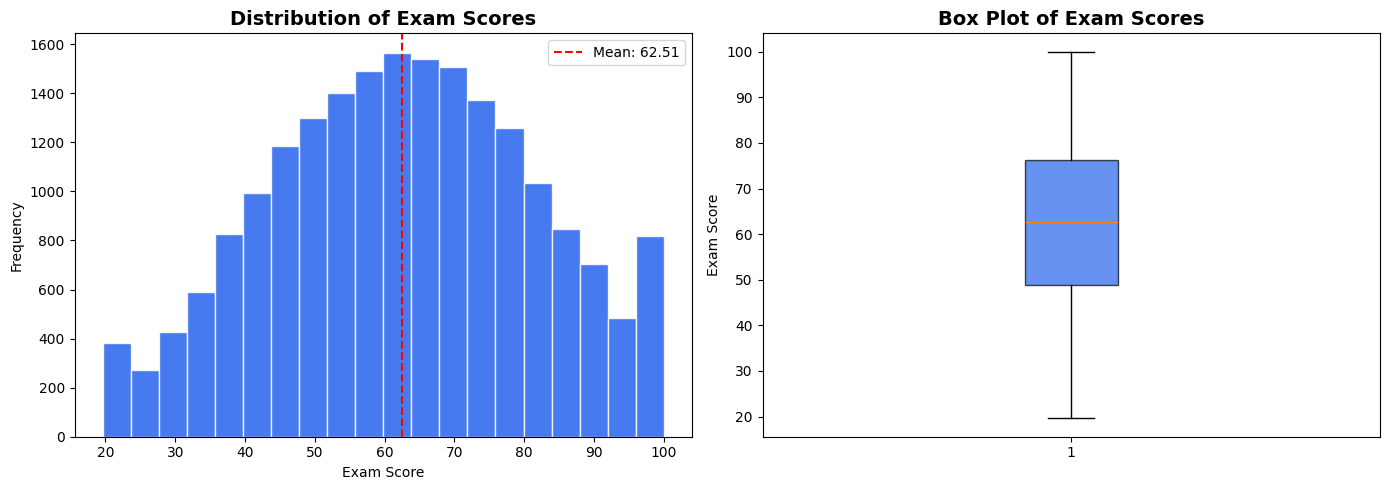

Mean: 62.51
Median: 62.60
Std Dev: 18.91
Skewness: -0.0491


In [93]:
# Distribution of Exam Scores (target variable)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['exam_score'], bins=20, color='#2563EB', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Exam Scores', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['exam_score'].mean(), color='red', linestyle='--', label=f"Mean: {df['exam_score'].mean():.2f}")
axes[0].legend()

# Box plot
axes[1].boxplot(df['exam_score'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#2563EB', alpha=0.7))
axes[1].set_title('Box Plot of Exam Scores', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Exam Score')

plt.tight_layout()
plt.show()

print(f'Mean: {df["exam_score"].mean():.2f}')
print(f'Median: {df["exam_score"].median():.2f}')
print(f'Std Dev: {df["exam_score"].std():.2f}')
print(f'Skewness: {df["exam_score"].skew():.4f}')

### 3.3 Feature Distributions

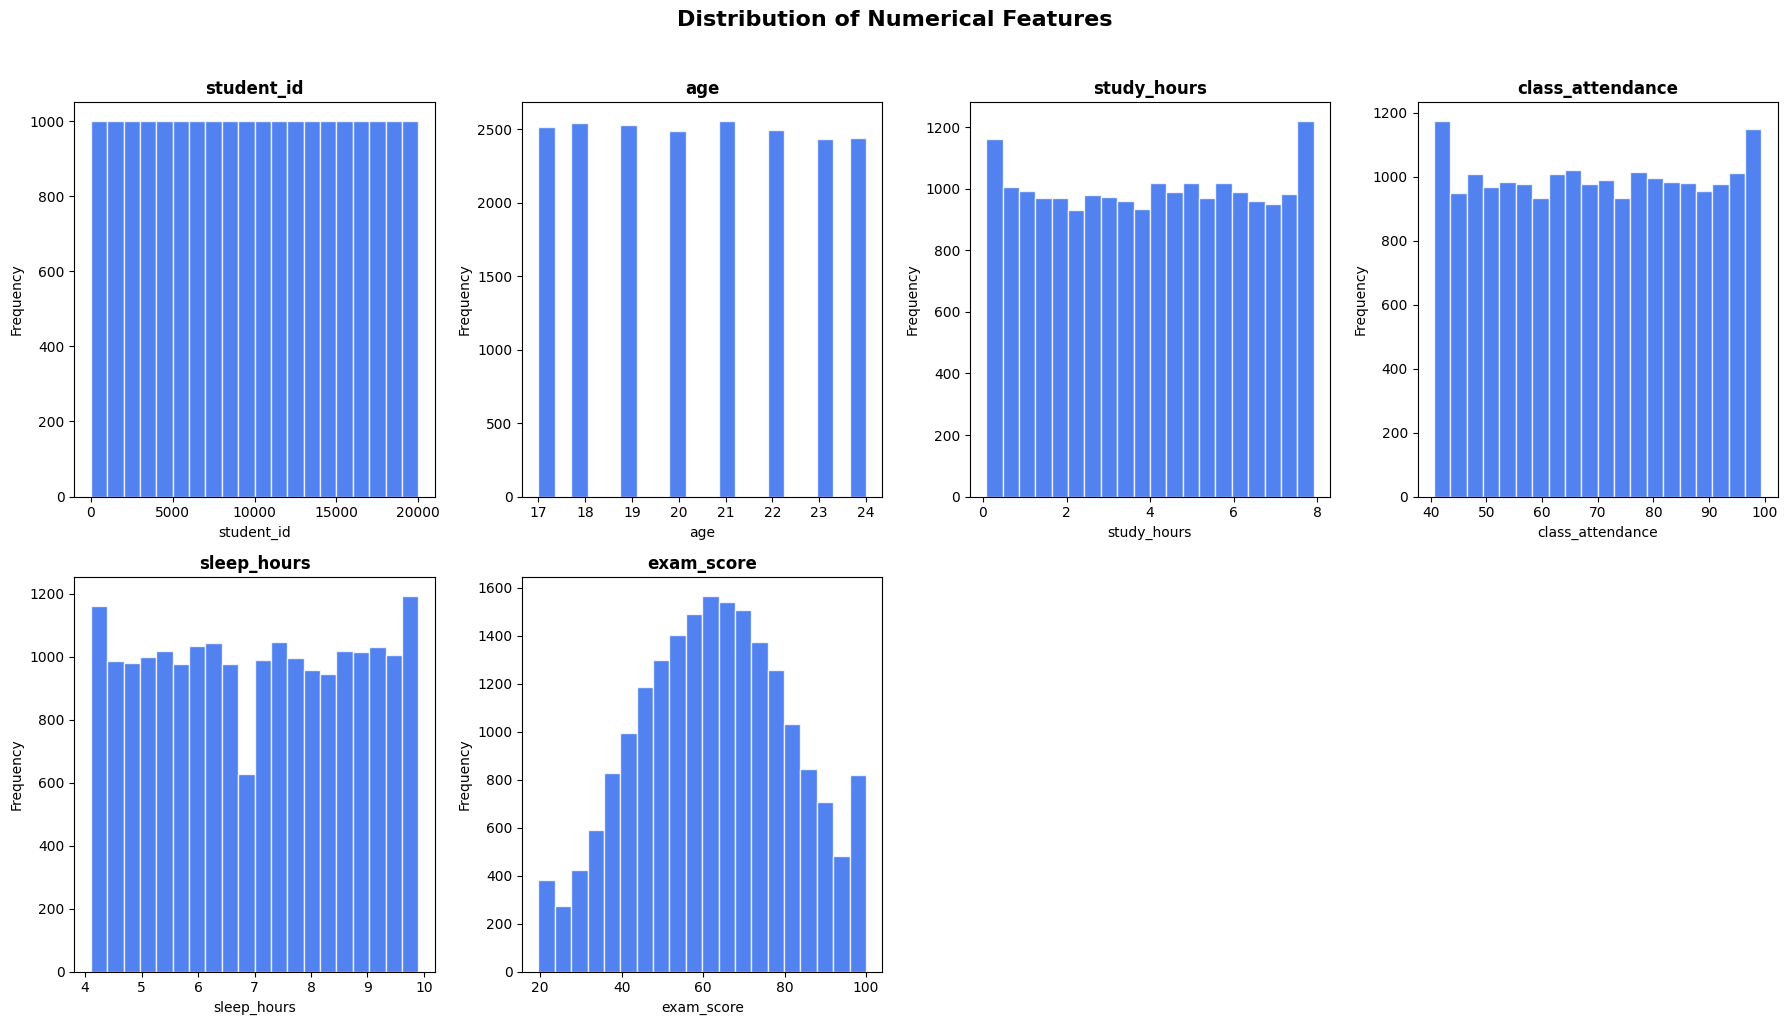

In [94]:
# Histograms for all numerical features
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    if i < len(axes):
        axes[i].hist(df[col].dropna(), bins=20, color='#2563EB', edgecolor='white', alpha=0.8)
        axes[i].set_title(col, fontsize=12, fontweight='bold')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

# Hide empty subplots
for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

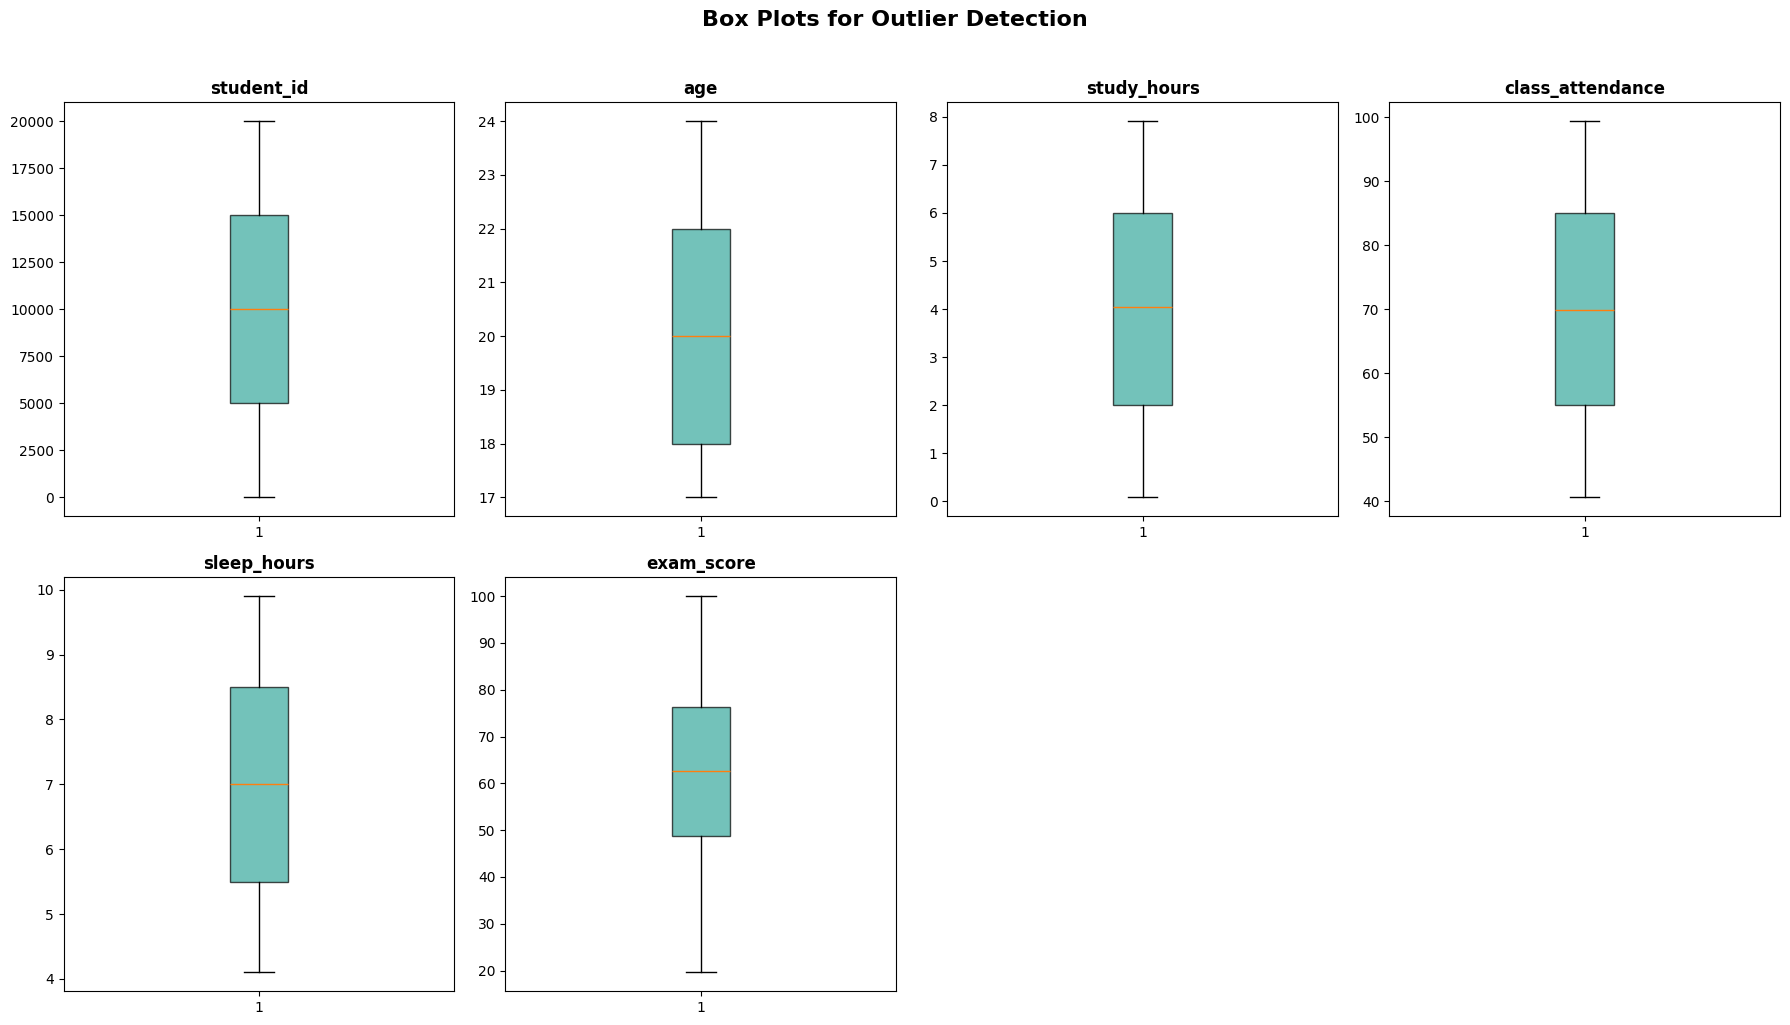

In [95]:
# Box plots for numerical features to detect outliers
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    if i < len(axes):
        axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                        boxprops=dict(facecolor='#38A89D', alpha=0.7))
        axes[i].set_title(col, fontsize=12, fontweight='bold')

for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots for Outlier Detection', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.4 Categorical Feature Analysis

Categorical columns: ['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']


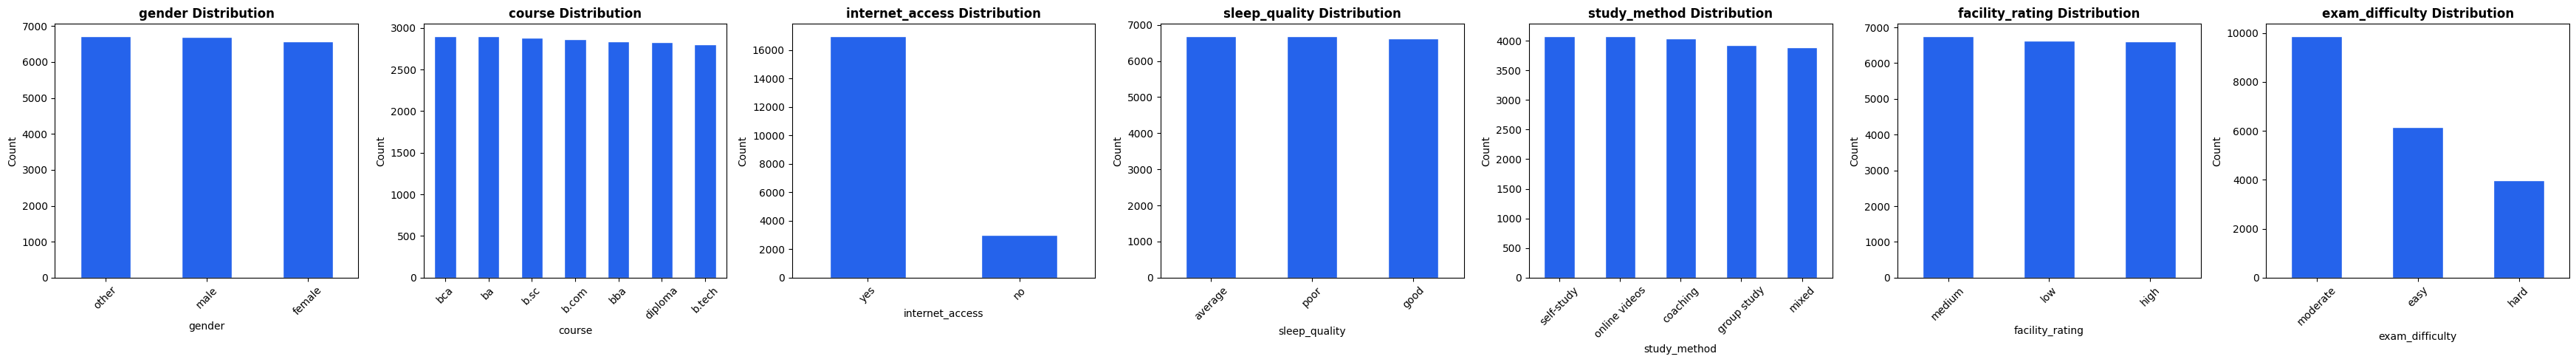

In [96]:
# Categorical feature distributions
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print('Categorical columns:', categorical_cols)

fig, axes = plt.subplots(1, len(categorical_cols), figsize=(5 * len(categorical_cols), 5))
if len(categorical_cols) == 1:
    axes = [axes]

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='#2563EB', edgecolor='white')
    axes[i].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

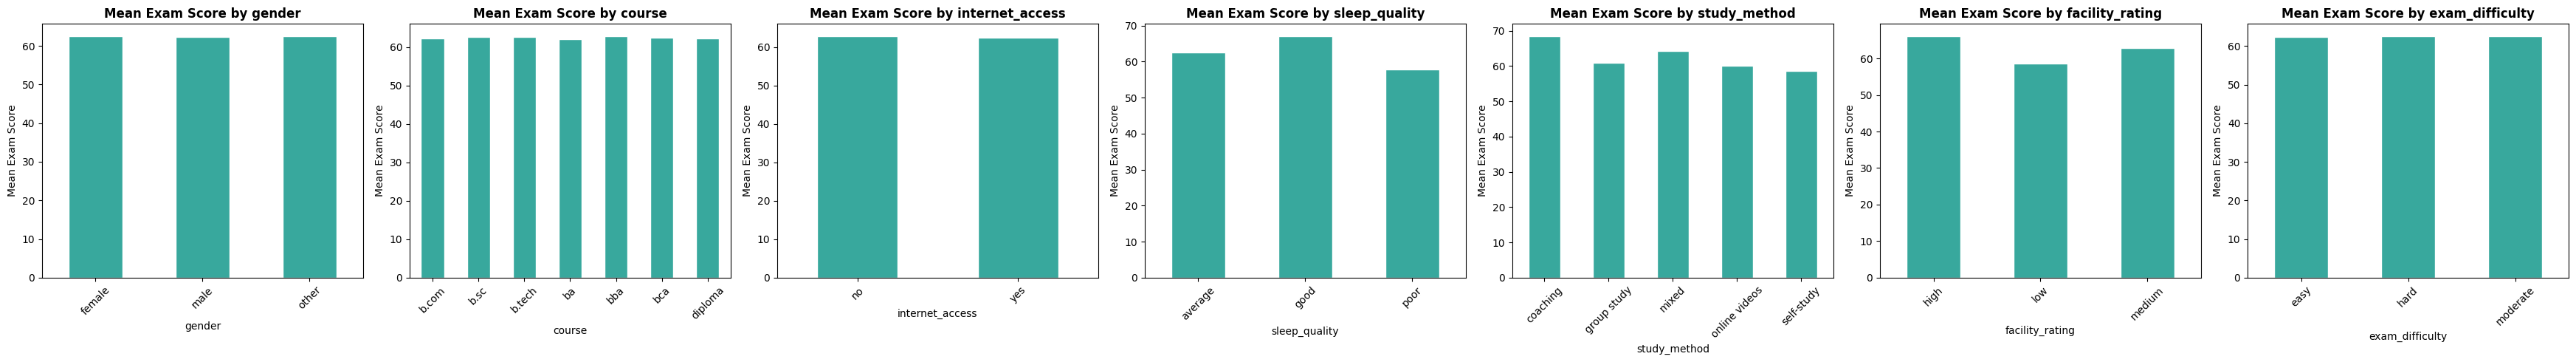

In [97]:
# Exam Score by categorical features
fig, axes = plt.subplots(1, len(categorical_cols), figsize=(5 * len(categorical_cols), 5))
if len(categorical_cols) == 1:
    axes = [axes]

for i, col in enumerate(categorical_cols):
    df.groupby(col)['exam_score'].mean().plot(kind='bar', ax=axes[i], color='#38A89D', edgecolor='white')
    axes[i].set_title(f'Mean Exam Score by {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Mean Exam Score')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 3.5 Correlation Analysis

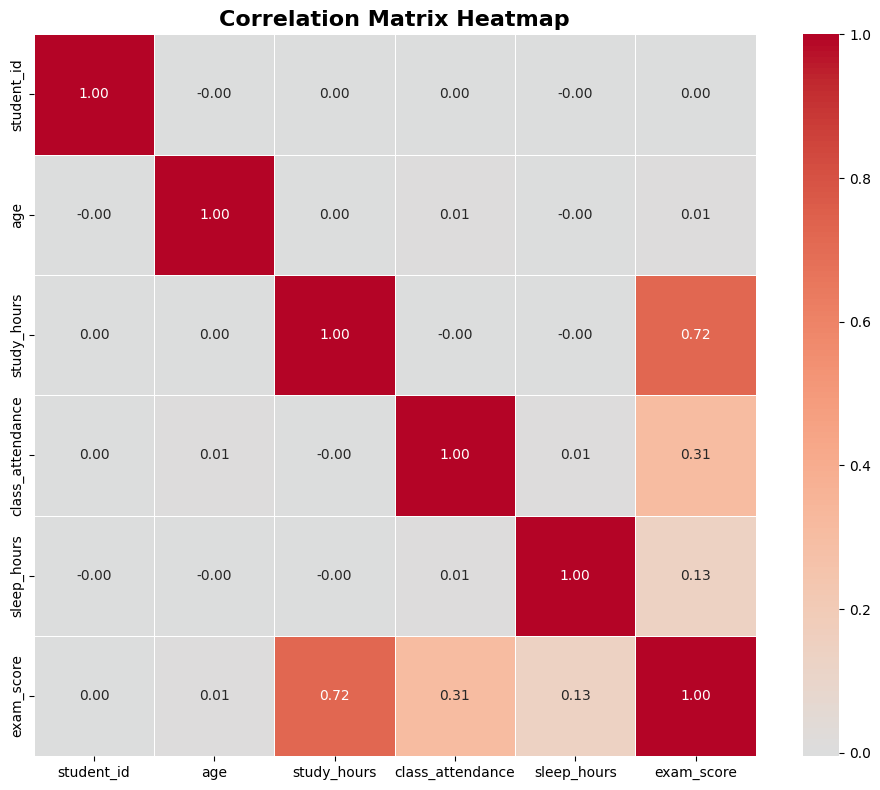


Correlation with exam_score:
exam_score          1.0000
study_hours         0.7178
class_attendance    0.3089
sleep_hours         0.1332
age                 0.0065
student_id          0.0033
Name: exam_score, dtype: float64


In [98]:
# Correlation matrix heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            linewidths=0.5, square=True)
plt.title('Correlation Matrix Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation with target
print('\nCorrelation with exam_score:')
print('=' * 40)
print(corr_matrix['exam_score'].sort_values(ascending=False).round(4))

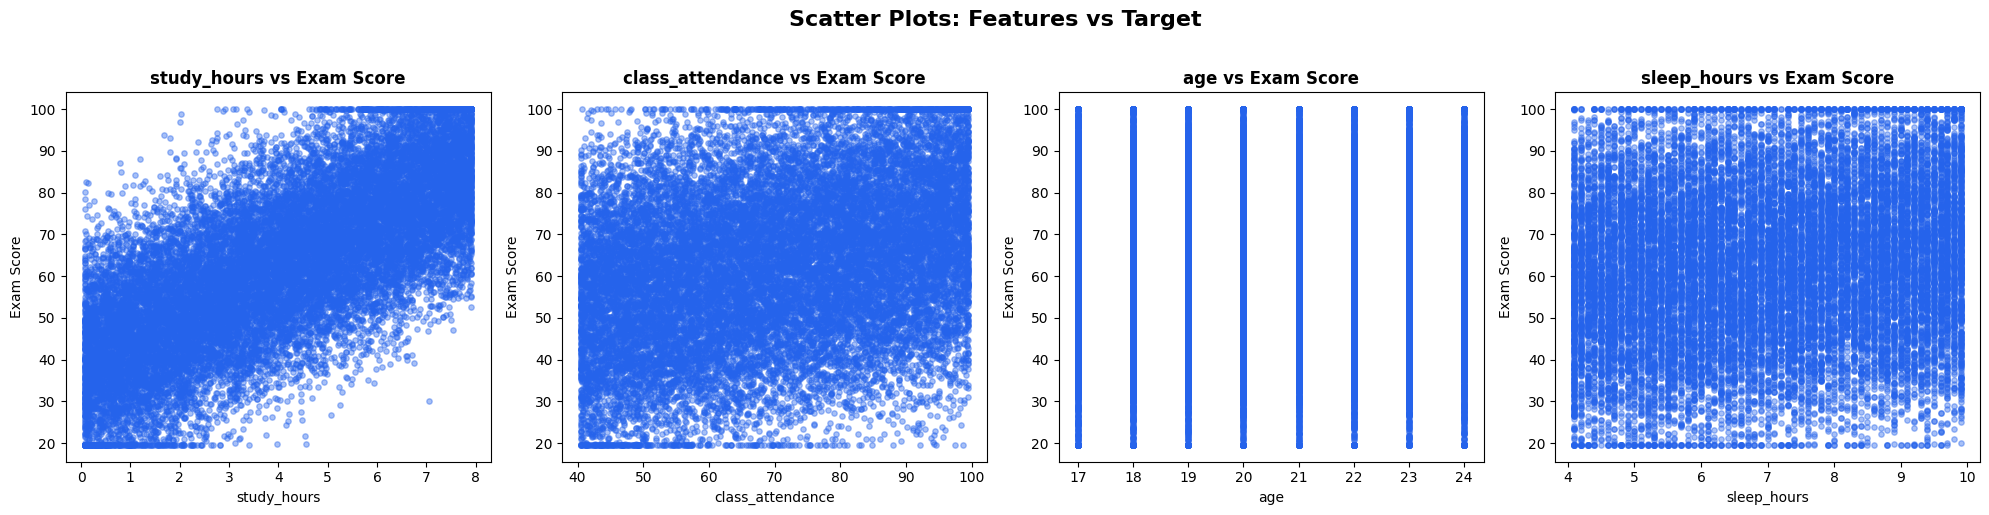

In [99]:
# Scatter plots: Key features vs Exam Score
key_features = ['study_hours', 'class_attendance', 'age', 'sleep_hours']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, feat in enumerate(key_features):
    axes[i].scatter(df[feat], df['exam_score'], alpha=0.4, color='#2563EB', s=15)
    axes[i].set_title(f'{feat} vs Exam Score', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Exam Score')

plt.suptitle('Scatter Plots: Features vs Target', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

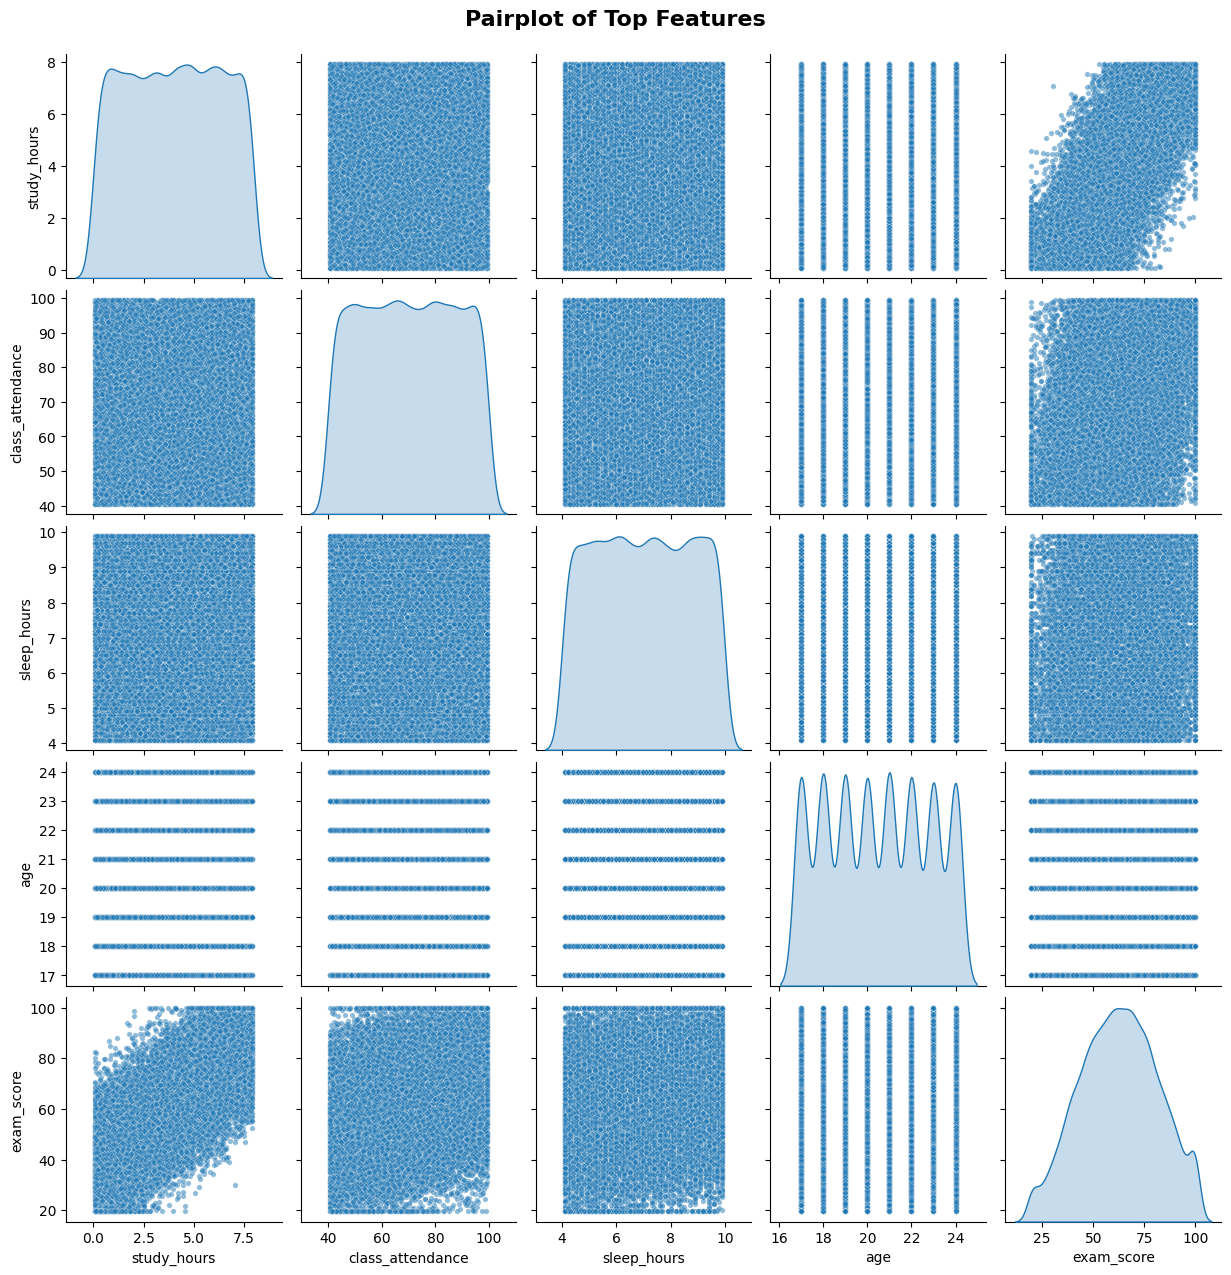

In [100]:
# Pairplot for top correlated features
top_features = ['study_hours', 'class_attendance', 'sleep_hours', 'age', 'exam_score']
sns.pairplot(df[top_features], diag_kind='kde', plot_kws={'alpha': 0.5, 's': 15})
plt.suptitle('Pairplot of Top Features', fontsize=16, fontweight='bold', y=1.02)
plt.show()

## 4. Data Preprocessing

### 4.1 Handle Missing Values

In [101]:
# Check missing values before treatment
print('Missing values BEFORE treatment:')
print(df.isnull().sum())
print()

# Impute missing values using median for numerical columns
imputer = SimpleImputer(strategy='median')
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = imputer.fit_transform(df[[col]])
        print(f'Imputed {col} with median value')

print('\nMissing values AFTER treatment:')
print(df.isnull().sum().sum(), 'total missing values')

Missing values BEFORE treatment:
student_id          0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64


Missing values AFTER treatment:
0 total missing values


### 4.2 Outlier Detection and Treatment

In [102]:
# Outlier detection using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return outliers, lower, upper

print('Outlier Detection (IQR Method):')
print('=' * 50)
for col in numerical_cols:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    if len(outliers) > 0:
        print(f'{col}: {len(outliers)} outliers detected (bounds: [{lower:.2f}, {upper:.2f}])')
    else:
        print(f'{col}: No outliers detected')

# Note: Outliers in Exam_Score kept as legitimate high performers

Outlier Detection (IQR Method):
student_id: No outliers detected
age: No outliers detected
study_hours: No outliers detected
class_attendance: No outliers detected
sleep_hours: No outliers detected
exam_score: No outliers detected


### 4.3 Encode Categorical Variables

In [103]:
# Encode categorical variables
df_encoded = df.copy()

# Label Encoding for ordinal features
ordinal_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
ordinal_cols = ['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level']

for col in ordinal_cols:
    if col in df_encoded.columns:
        df_encoded[col] = df_encoded[col].map(ordinal_mapping)
        print(f'Label Encoded: {col} -> Low=0, Medium=1, High=2')

# One-Hot Encoding for nominal features
if 'Gender' in df_encoded.columns:
    df_encoded = pd.get_dummies(df_encoded, columns=['Gender'], drop_first=True)
    print('One-Hot Encoded: Gender')

print('\nEncoded DataFrame shape:', df_encoded.shape)
df_encoded.head()


Encoded DataFrame shape: (20000, 13)


,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


### 4.4 Feature Scaling and Train-Test Split

In [104]:
# Separate features and target
X = df_encoded.drop('exam_score', axis=1)
y = df_encoded['exam_score']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'Feature names: {X.columns.tolist()}')

Features shape: (20000, 12)
Target shape: (20000,)
Feature names: ['student_id', 'age', 'gender', 'course', 'study_hours', 'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']


In [105]:
# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')

Training set: 16000 samples
Test set: 4000 samples


In [106]:
# Feature Scaling using StandardScaler

# First, handle categorical columns in X_train and X_test BEFORE scaling
# Identify categorical columns that are still objects
categorical_cols_to_encode = X_train.select_dtypes(include=['object']).columns.tolist()

# Define mappings for ordinal and binary features
sleep_quality_mapping = {'poor': 0, 'average': 1, 'good': 2, 'excellent': 3}
facility_rating_mapping = {'low': 0, 'medium': 1, 'high': 2}
exam_difficulty_mapping = {'easy': 0, 'moderate': 1, 'hard': 2}
internet_access_mapping = {'no': 0, 'yes': 1} # binary, can be label encoded

# Apply ordinal mapping to X_train and X_test
for df_set in [X_train, X_test]:
    if 'sleep_quality' in df_set.columns:
        df_set['sleep_quality'] = df_set['sleep_quality'].map(sleep_quality_mapping)
    if 'facility_rating' in df_set.columns:
        df_set['facility_rating'] = df_set['facility_rating'].map(facility_rating_mapping)
    if 'exam_difficulty' in df_set.columns:
        df_set['exam_difficulty'] = df_set['exam_difficulty'].map(exam_difficulty_mapping)
    if 'internet_access' in df_set.columns:
        df_set['internet_access'] = df_set['internet_access'].map(internet_access_mapping)


# Identify remaining nominal categorical columns for One-Hot Encoding
# After manual mapping, 'gender', 'course', 'study_method' should be left as objects
nominal_cols_for_ohe = [col for col in categorical_cols_to_encode if col not in ['sleep_quality', 'facility_rating', 'exam_difficulty', 'internet_access']]

# Apply One-Hot Encoding to X_train and X_test
# Combine for consistent one-hot encoding across train/test sets
X_combined = pd.concat([X_train, X_test], ignore_index=True)
X_combined_encoded = pd.get_dummies(X_combined, columns=nominal_cols_for_ohe, drop_first=True)

X_train = X_combined_encoded.iloc[:len(X_train)]
X_test = X_combined_encoded.iloc[len(X_train):]


# Now all features are numerical, proceed with scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Feature scaling applied (StandardScaler: mean=0, std=1)')
print(f'Scaled training set mean (sample): {X_train_scaled.mean(axis=0)[:3].round(4)}')
print(f'Scaled training set std (sample): {X_train_scaled.std(axis=0)[:3].round(4)}')

Feature scaling applied (StandardScaler: mean=0, std=1)
Scaled training set mean (sample): [-0.  0.  0.]
Scaled training set std (sample): [1. 1. 1.]


## 5. Model Training

We will train four regression models:
1. **Linear Regression** - Baseline model
2. **Decision Tree Regressor** - Non-linear, interpretable
3. **Random Forest Regressor** - Ensemble bagging method
4. **Gradient Boosting Regressor** - Ensemble boosting method

In [107]:
# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Train and evaluate each model
results = []

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred_test)
    mse = mean_squared_error(y_test, y_pred_test)
    rmse = np.sqrt(mse)
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')

    results.append({
        'Model': name,
        'MAE': round(mae, 4),
        'MSE': round(mse, 4),
        'RMSE': round(rmse, 4),
        'R2 (Train)': round(r2_train, 4),
        'R2 (Test)': round(r2_test, 4),
        'CV Mean R2': round(cv_scores.mean(), 4),
        'CV Std': round(cv_scores.std(), 4)
    })

    print(f'{name}:')
    print(f'  MAE={mae:.4f}, RMSE={rmse:.4f}, R2(Test)={r2_test:.4f}, CV={cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
    print()

# Results table
results_df = pd.DataFrame(results)
print('\n' + '=' * 80)
print('MODEL COMPARISON TABLE')
print('=' * 80)
results_df

Linear Regression:
  MAE=7.8623, RMSE=9.7708, R2(Test)=0.7331, CV=0.7310 +/- 0.0071

Decision Tree:
  MAE=12.2818, RMSE=15.4044, R2(Test)=0.3366, CV=0.3546 +/- 0.0222

Random Forest:
  MAE=8.5345, RMSE=10.5898, R2(Test)=0.6865, CV=0.6849 +/- 0.0087

Gradient Boosting:
  MAE=7.9894, RMSE=9.9065, R2(Test)=0.7256, CV=0.7229 +/- 0.0063


MODEL COMPARISON TABLE


,Model,MAE,MSE,RMSE,R2 (Train),R2 (Test),CV Mean R2,CV Std
0,Linear Regression,7.8623,95.4687,9.7708,0.7319,0.7331,0.7310,0.0071
1,Decision Tree,12.2818,237.2958,15.4044,1.0000,0.3366,0.3546,0.0222
2,Random Forest,8.5345,112.1431,10.5898,0.9562,0.6865,0.6849,0.0087
3,Gradient Boosting,7.9894,98.1387,9.9065,0.7399,0.7256,0.7229,0.0063


### 5.1 Model Comparison Visualization

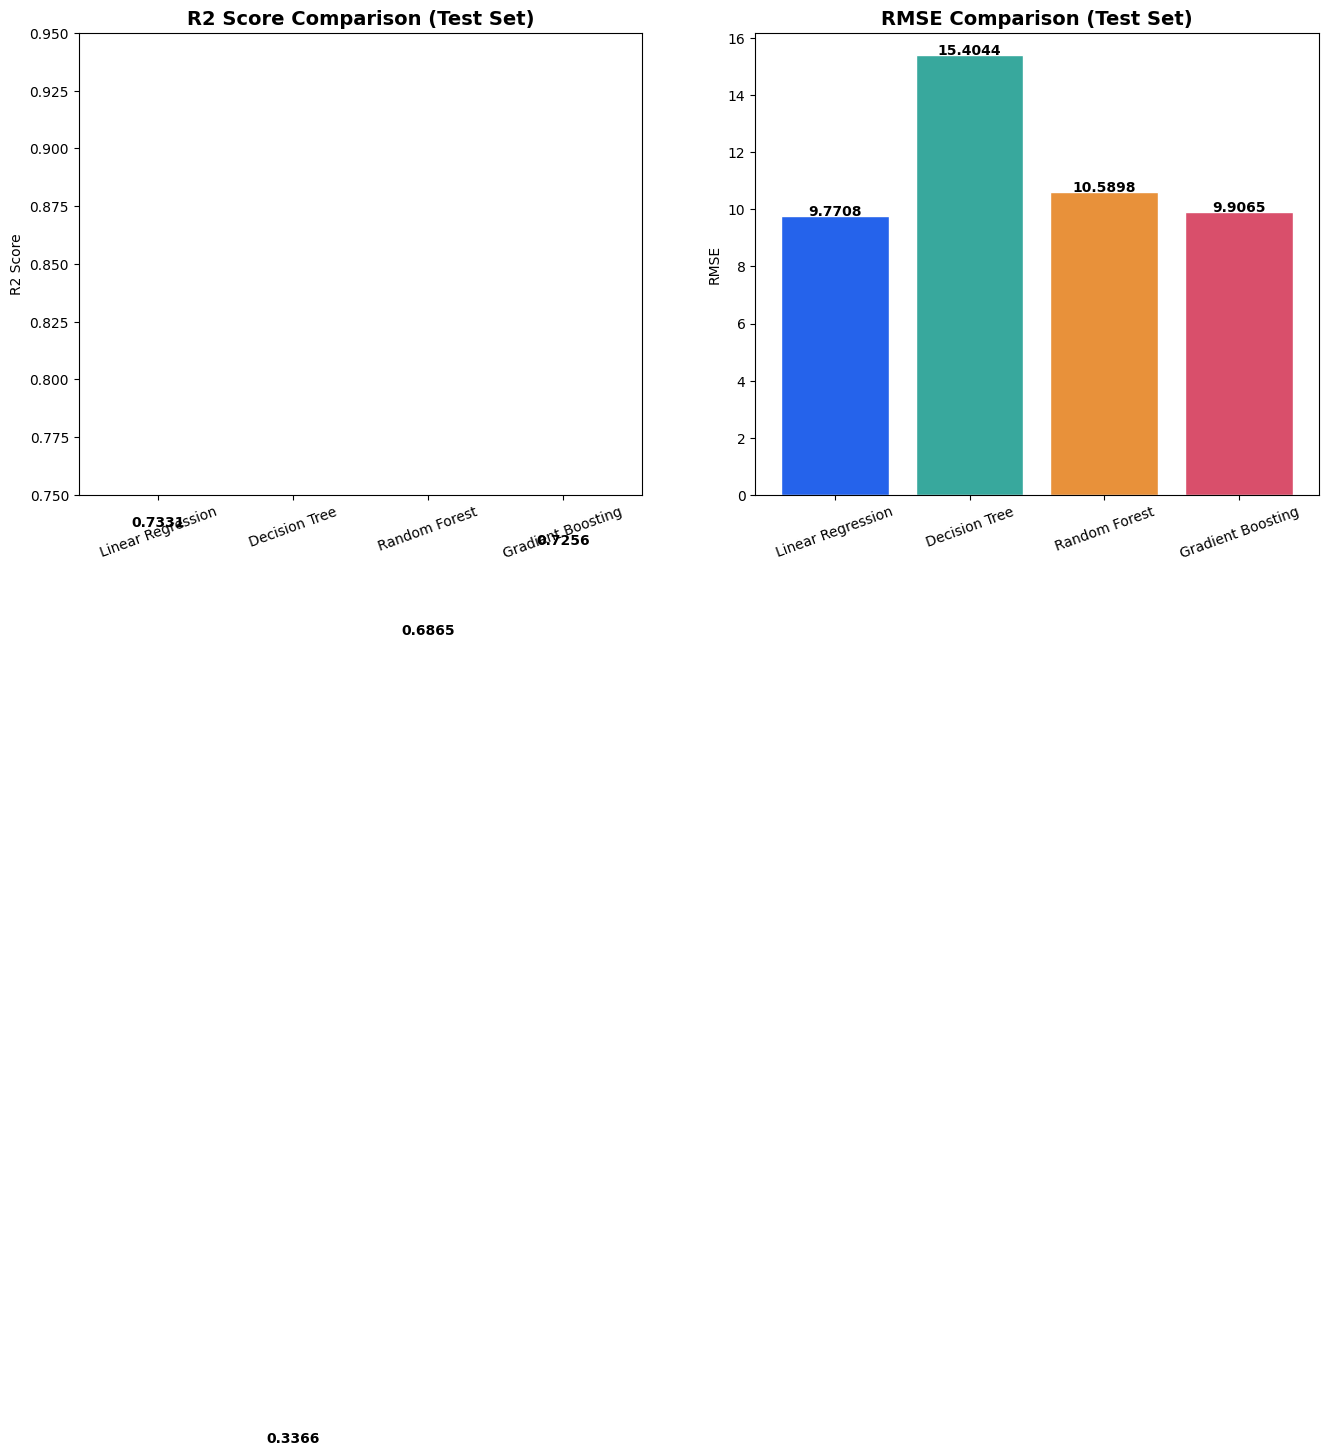

In [108]:
# Bar chart comparing model R2 scores
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R2 Score Comparison
colors = ['#2563EB', '#38A89D', '#E8913A', '#D94F6B']
bars = axes[0].bar(results_df['Model'], results_df['R2 (Test)'], color=colors, edgecolor='white')
axes[0].set_title('R2 Score Comparison (Test Set)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('R2 Score')
axes[0].set_ylim(0.75, 0.95)
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, results_df['R2 (Test)']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)

# RMSE Comparison
bars2 = axes[1].bar(results_df['Model'], results_df['RMSE'], color=colors, edgecolor='white')
axes[1].set_title('RMSE Comparison (Test Set)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=20)
for bar, val in zip(bars2, results_df['RMSE']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## 6. Hyperparameter Tuning (GridSearchCV)

We tune the top 3 non-linear models using GridSearchCV with 5-fold cross-validation.

In [109]:
# === Decision Tree Tuning ===
dt_params = {
    'max_depth': [3, 5, 8, 10, 15],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8]
}

dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_params, cv=5, scoring='r2', n_jobs=-1, verbose=0
)
dt_grid.fit(X_train_scaled, y_train)

print('Decision Tree - Best Parameters:', dt_grid.best_params_)
print('Decision Tree - Best CV R2 Score:', round(dt_grid.best_score_, 4))

Decision Tree - Best Parameters: {'max_depth': 8, 'min_samples_leaf': 8, 'min_samples_split': 2}
Decision Tree - Best CV R2 Score: 0.6361


In [110]:
# === Random Forest Tuning ===
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params, cv=5, scoring='r2', n_jobs=-1, verbose=0
)
rf_grid.fit(X_train_scaled, y_train)

print('Random Forest - Best Parameters:', rf_grid.best_params_)
print('Random Forest - Best CV R2 Score:', round(rf_grid.best_score_, 4))

Random Forest - Best Parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 300}
Random Forest - Best CV R2 Score: 0.6894


In [111]:
# === Gradient Boosting Tuning ===
gb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_params, cv=5, scoring='r2', n_jobs=-1, verbose=0
)
gb_grid.fit(X_train_scaled, y_train)

print('Gradient Boosting - Best Parameters:', gb_grid.best_params_)
print('Gradient Boosting - Best CV R2 Score:', round(gb_grid.best_score_, 4))

Gradient Boosting - Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300}
Gradient Boosting - Best CV R2 Score: 0.7257


### 6.1 Evaluate Tuned Models

In [112]:
# Evaluate all tuned models
tuned_models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree (Tuned)': dt_grid.best_estimator_,
    'Random Forest (Tuned)': rf_grid.best_estimator_,
    'Gradient Boosting (Tuned)': gb_grid.best_estimator_
}

tuned_results = []

for name, model in tuned_models.items():
    if name == 'Linear Regression':
        model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    tuned_results.append({
        'Model': name,
        'MAE': round(mae, 4),
        'MSE': round(mse, 4),
        'RMSE': round(rmse, 4),
        'R2': round(r2, 4)
    })

    print(f'{name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}')

tuned_results_df = pd.DataFrame(tuned_results)
print('\n' + '=' * 70)
print('TUNED MODEL COMPARISON')
print('=' * 70)
tuned_results_df

Linear Regression: MAE=7.8623, RMSE=9.7708, R2=0.7331
Decision Tree (Tuned): MAE=9.1635, RMSE=11.3459, R2=0.6401
Random Forest (Tuned): MAE=8.4986, RMSE=10.4909, R2=0.6923
Gradient Boosting (Tuned): MAE=7.9320, RMSE=9.8513, R2=0.7287

TUNED MODEL COMPARISON


,Model,MAE,MSE,RMSE,R2
0,Linear Regression,7.8623,95.4687,9.7708,0.7331
1,Decision Tree (Tuned),9.1635,128.7287,11.3459,0.6401
2,Random Forest (Tuned),8.4986,110.0590,10.4909,0.6923
3,Gradient Boosting (Tuned),7.9320,97.0474,9.8513,0.7287


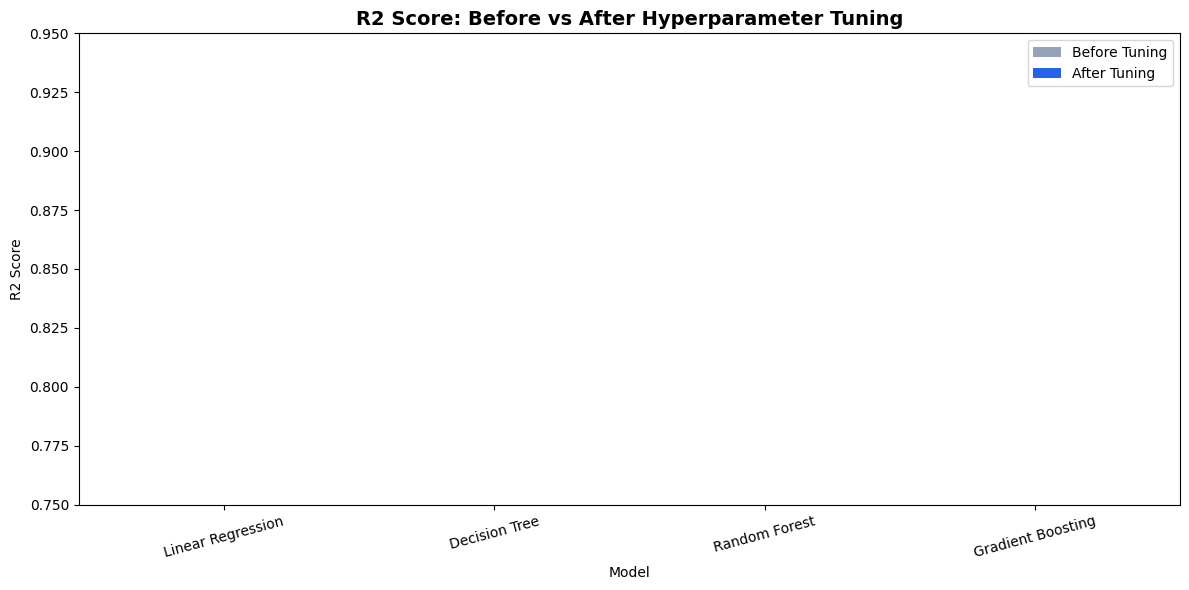

In [113]:
# Before vs After Tuning Comparison
fig, ax = plt.subplots(figsize=(12, 6))

models_list = ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']
before_r2 = results_df['R2 (Test)'].tolist()
after_r2 = tuned_results_df['R2'].tolist()

x = np.arange(len(models_list))
width = 0.35

bars1 = ax.bar(x - width/2, before_r2, width, label='Before Tuning', color='#94A3B8')
bars2 = ax.bar(x + width/2, after_r2, width, label='After Tuning', color='#2563EB')

ax.set_xlabel('Model')
ax.set_ylabel('R2 Score')
ax.set_title('R2 Score: Before vs After Hyperparameter Tuning', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=15)
ax.legend()
ax.set_ylim(0.75, 0.95)

plt.tight_layout()
plt.show()

## 7. Best Model Evaluation

The **Gradient Boosting (Tuned)** model achieved the highest R2 score. Let's perform detailed evaluation.

In [114]:
# Best model: Gradient Boosting (Tuned)
best_model = gb_grid.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

print('Best Model: Gradient Boosting (Tuned)')
print('Best Parameters:', gb_grid.best_params_)
print(f'MAE:  {mean_absolute_error(y_test, y_pred_best):.4f}')
print(f'MSE:  {mean_squared_error(y_test, y_pred_best):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):.4f}')
print(f'R2:   {r2_score(y_test, y_pred_best):.4f}')

Best Model: Gradient Boosting (Tuned)
Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300}
MAE:  7.9320
MSE:  97.0474
RMSE: 9.8513
R2:   0.7287


### 7.1 Actual vs Predicted Plot

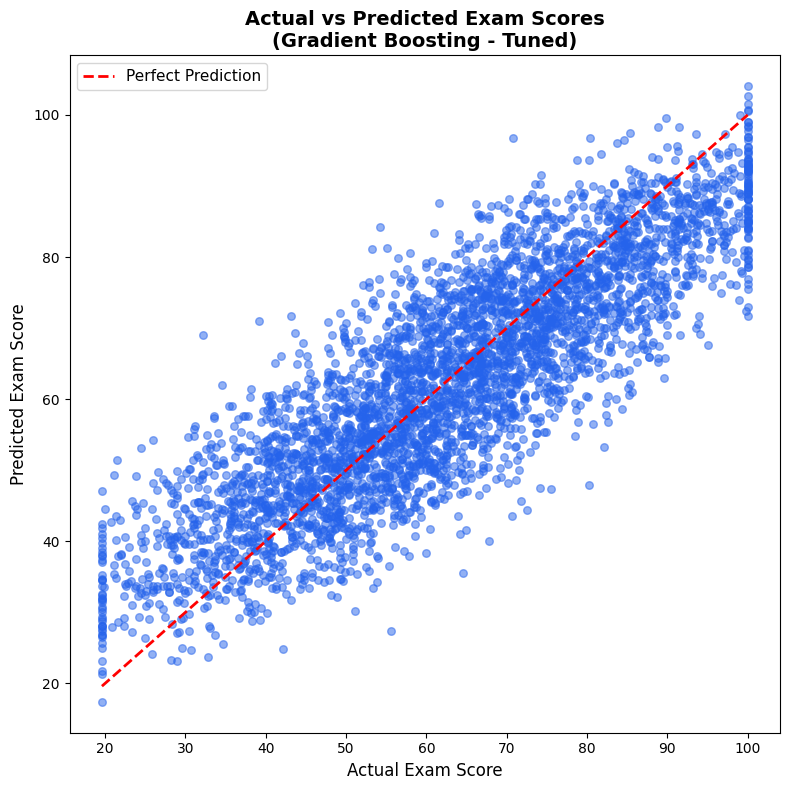

In [115]:
# Actual vs Predicted scatter plot
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_best, alpha=0.5, color='#2563EB', s=30)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Exam Score', fontsize=12)
plt.ylabel('Predicted Exam Score', fontsize=12)
plt.title('Actual vs Predicted Exam Scores\n(Gradient Boosting - Tuned)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 7.2 Residual Analysis

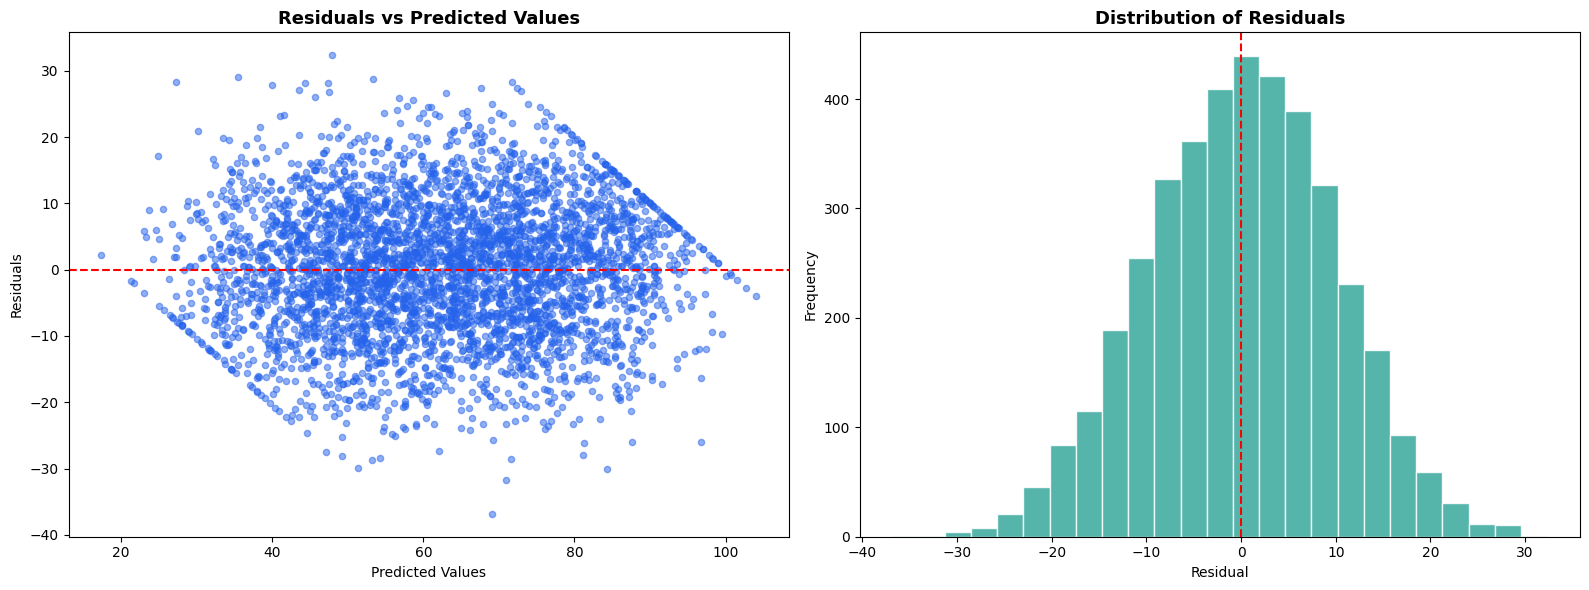

Mean Residual: 0.0651
Std Residual: 9.8523


In [116]:
# Residual analysis
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Residuals vs Predicted
axes[0].scatter(y_pred_best, residuals, alpha=0.5, color='#2563EB', s=20)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted Values', fontsize=13, fontweight='bold')

# Residual distribution
axes[1].hist(residuals, bins=25, color='#38A89D', edgecolor='white', alpha=0.85)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Mean Residual: {residuals.mean():.4f}')
print(f'Std Residual: {residuals.std():.4f}')

### 7.3 Feature Importance

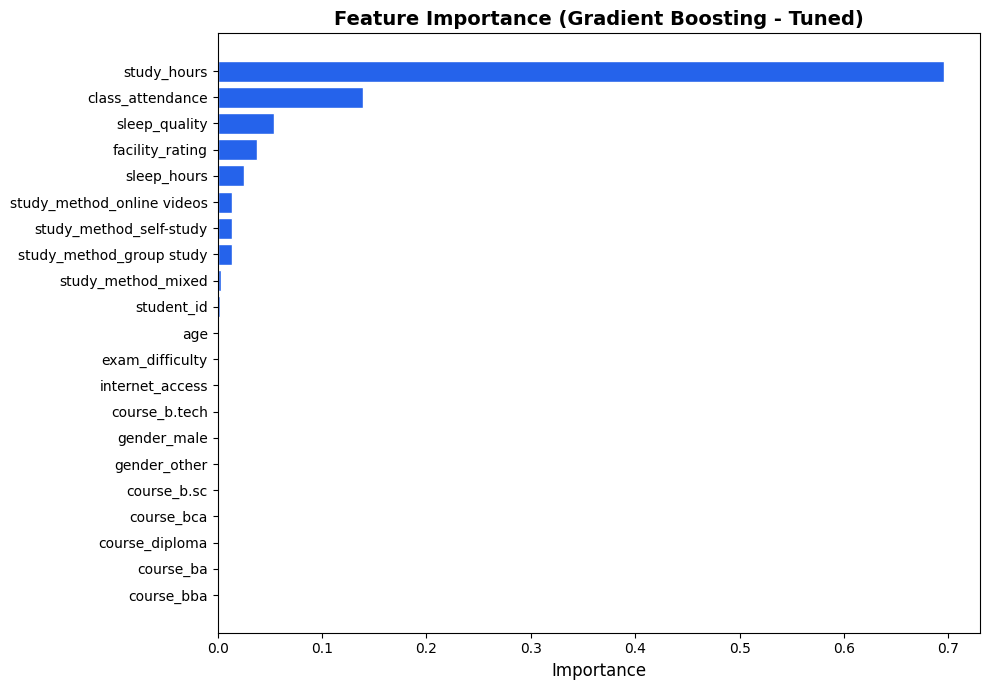


Feature Importance Ranking:
study_hours               0.6955
class_attendance          0.1396
sleep_quality             0.0538
facility_rating           0.0375
sleep_hours               0.0257
study_method_online videos 0.0141
study_method_self-study   0.0140
study_method_group study  0.0134
study_method_mixed        0.0029
student_id                0.0027
age                       0.0002
exam_difficulty           0.0001
internet_access           0.0001
course_b.tech             0.0001
gender_male               0.0001
gender_other              0.0001
course_b.sc               0.0001
course_bca                0.0000
course_diploma            0.0000
course_ba                 0.0000
course_bba                0.0000


In [119]:
# Feature importance from Gradient Boosting
feature_names = X_train.columns.tolist() # Corrected: Get column names after all encoding steps
importances = best_model.feature_importances_

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='#2563EB', edgecolor='white')
plt.xlabel('Importance', fontsize=12)
plt.title('Feature Importance (Gradient Boosting - Tuned)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nFeature Importance Ranking:')
print('=' * 40)
for _, row in feat_imp_df.sort_values('Importance', ascending=False).iterrows():
    print(f"{row['Feature']:25s} {row['Importance']:.4f}")